# AV4

## Questão 1: Implemente o seguinte circuito quântico.

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2, EstimatorV2, QiskitRuntimeService
from qiskit.circuit import Parameter
from qiskit.visualization import plot_distribution, plot_histogram
import numpy as np

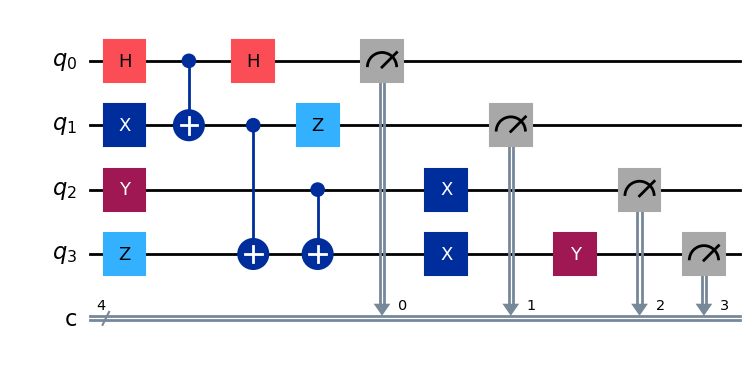

In [3]:
# Cria os qubits
qubits = QuantumRegister(4,'q')

# Cria os bits clássicos
bits = ClassicalRegister(4,'c')

# Criar um circuito com 6 qubits
qc = QuantumCircuit(qubits, bits)

# Aplicar portas quânticas iniciais
qc.h(0)       # Hadamard em q0
qc.x(1)       # X em q1
qc.y(2)       # Y em q2
qc.z(3)       # Z em q3

# Aplicar portas CNOT para criar emaranhamento
qc.cx(0, 1)   # CNOT (q0 controla q1)
qc.cx(1, 3)   # CNOT (q1 controla q3)
qc.cx(2, 3)   # CNOT (q2 controla q3)

# Aplicar portas adicionais após os CNOTs
qc.h(0)       # Hadamard em q0
qc.z(1)       # Z em q1
qc.x(2)       # X em q2
qc.x(3)       # X em q3
qc.y(3)       # Y em q3

qc.measure(qubits, bits)
qc.draw('mpl', filename='AV4_questao1.png')

## Questão 2: Transpile o circuito acima com o AerSimulator

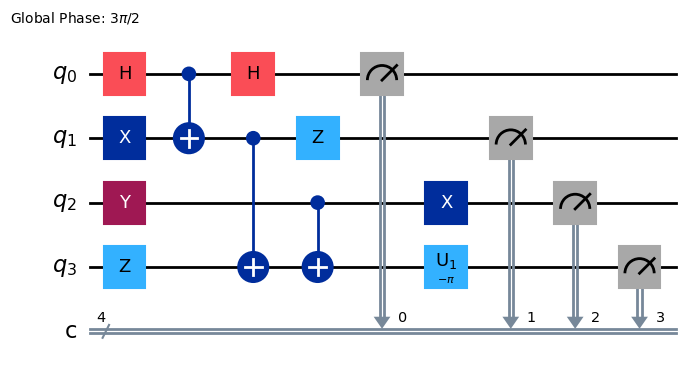

In [4]:
# backend simulado
backend_aer = AerSimulator()

# AerSimulator QC
qc_aer = transpile(qc, backend=backend_aer)
qc_aer.draw('mpl', filename='AV4_questao2.png')

## Questão 3: Converta o Timetabling Problem para um problema QUBO

O **Timetabling Problem** é um problema de alocação de recursos ao longo do tempo, onde um conjunto de eventos (como aulas, reuniões ou turnos de trabalho) deve ser distribuído em determinados horários, garantindo que restrições sejam atendidas. 

O objetivo geralmente é minimizar custos ou maximizar a eficiência da alocação, levando em conta preferências e limitações.

No modelo apresentado abaixo, o Timetabling Problem é formulado como um problema de otimização, onde buscamos atribuir professores a turmas em determinados horários, minimizando um custo associado a cada alocação. A função objetivo H é definida como:

$$H = \sum_{t=1}^{2} \sum_{p=1}^{2} \sum_{c=1}^{2} C_{t, p, c} \cdot x_{t, p, c}$$

Aqui, $x_{t, p, c}$ é uma variável binária que assume valor 1 se o professor $p$ estiver alocado à turma $c$ no horário $t$, e 0 caso contrário.

$$x_{c, p, t} =
\begin{cases}
1, & \text{se a turma } c \text{ tiver aula com o professor } p \text{ no horário } t \\
0, & \text{caso contrário}
\end{cases}$$


Cada coeficiente da função objetivo representa um custo associado a essa alocação. O objetivo é encontrar a configuração de $x_{t, p, c}$ que minimize H, garantindo que todas as aulas sejam alocadas corretamente, respeitando restrições como cada turma ter exatamente um professor por horário e nenhum professor estar em dois lugares ao mesmo tempo.

Considerando a função objetivo e a restrição abaixo, converta-o para um problema **QUBO** e encontre o conjunto de bits que indica a solução ótima, ou seja, a primeira melhor combinação entre **turma, professor e horário**.

**Função Objetivo:**
$$H = 3x_{1,1,1} + 5x_{1,1,2} + 2x_{1,2,1} + 4x_{1,2,2} + 6x_{2,1,1} + 2x_{2,1,2} + 3x_{2,2,1} + 6x_{2,2,2}$$

**Restrição - Um professor não pode estar em mais de uma turma no mesmo horário:**

$x_{1,1,1} + x_{1,1,2} \leq 1$

$x_{1,2,1} + x_{1,2,2} \leq 1$

$x_{2,1,1} + x_{2,1,2} \leq 1$

$x_{2,2,1} + x_{2,2,2} \leq 1$

Ou seja, ao tranformar essa restrição para QUBO, o resultado deve ser no máximo 1.

In [6]:
import numpy as np

# v = 4  # vértices (cidades)
n = 8  # arestas (rotas)

# matriz nula com n dimensões, sendo cada dimensão composta por uma matriz nxn
# receberá valores -1, 0, 1 na diagonal principal
z = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128 )

# mesmo princípio da matriz z 
# futuramente, aplicando (1 - PauliZ)/2, converterá os valores da matriz z acima para 0 e 1
# ela será populada com os valores da função objetivo na diagonal principal
zI = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128 )

# matriz identidade nxn
Id = np.identity( 2**n , dtype=np.complex128 )

# matriz de Pauli Z
sigmaz = np.array([ [1,0] , [0,-1] ])

# cria o hamiltoniano
for k in range(0, n):
    z[k] = np.kron( np.identity(2**k) , np.kron(sigmaz , np.identity(2**(n-1-k))) )
    zI[k] = (Id - z[k]) / 2

# função objetivo
Hc = 3*zI[0] + 5*zI[1] + 2*zI[2] + 4*zI[3] + 6*zI[4] + 2*zI[5] + 3*zI[6] + 6*zI[7]

# restrição 1
M1 = 100
Hc += M1 * ((zI[0] + zI[1] + zI[2] + zI[3] + zI[4] + zI[5] + zI[6] + zI[7] - 1*Id))**2

# menor valor
menor_valor = np.min(np.diag(Hc))
menor_valor

# posição do menor valor
posicao = np.unravel_index(np.argmin(np.diag(Hc)), np.diag(Hc).shape)
posicao = int(posicao[0])
posicao

# Resposta
# Converter para binário com n dígitos
format(posicao, f'0{n}b')

'00000100'